# Using Convolutional Neural Networks for Low-Resolution Image Upscaling
## (Image Restoration and Enhancement)
## Author: Niraj Thapaliya

In [ ]:
import os, time, shutil, logging

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
logging.disable(logging.WARNING)

import tensorflow as tf
import keras
from keras import layers, callbacks, ops

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image
from tensorflow.image import psnr

%config InlineBackend.figure_format = 'retina'
print("Tensorflow version:", tf.__version__)
print("Keras version:", keras.__version__)

### 1. Data pipeline setup, helper functions, and common code

Unix commands to set up directories and download dataset:

```bash
uv sync
mkdir -p data/train
mkdir -p data/test
cd data/train

uv run kaggle datasets download arnaud58/flickrfaceshq-dataset-ffhq
unzip -u flickrfaceshq-dataset-ffhq.zip
```

Additional python commands to create the test set, this needs to be run only once:

```python
import glob, shutil

for to_file in np.random.choice(glob.glob('data/train/*.png'), size=5000, replace=False):
    shutil.move(to_file, to_file.replace('train', 'test'))
```

In [ ]:
train_dir = "data/train"
test_dir = "data/test"

In [ ]:
model_path = "models"
random_seed = 1863
batch_size = 20
image_height = 256
scale_factor = 4

image_size_full = (image_height, image_height)
image_size_down = (image_height // scale_factor, image_height // scale_factor)
model_input_shape = (*image_size_down, 3)

Import data from directory and rescale.

In [ ]:
dataset_train = keras.utils.image_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    image_size=image_size_full,
    labels=None,
    seed=random_seed,
    subset="training",
    validation_split=0.20,
).map(lambda x: x / 255.0)

dataset_val = keras.utils.image_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    image_size=image_size_full,
    labels=None,
    seed=random_seed,
    subset="validation",
    validation_split=0.20,
).map(lambda x: x / 255.00)

dataset_test = keras.utils.image_dataset_from_directory(
    test_dir,
    batch_size=batch_size,
    image_size=image_size_full,
    labels=None,
    seed=random_seed,
).map(lambda x: x / 255.0)

In [ ]:
downscaler = keras.layers.Resizing(*image_size_down, interpolation="bilinear")
upscaler = keras.layers.Resizing(*image_size_full, interpolation="bilinear")


def prepare_images(img):
    return (downscaler(img), img)

In [ ]:
dataset_train = dataset_train.map(prepare_images)
dataset_val = dataset_val.map(prepare_images)

Some common functions and helper code for later.

In [ ]:
def train_model(model, model_name, epochs=10):
    model_fullpath = os.path.join(model_path, model_name + ".keras")
    history_fullpath = os.path.join(model_path, model_name + "-history.csv")
    stats_fullpath = os.path.join(model_path, model_name + "-stats.csv")

    if not os.path.isfile(model_fullpath):
        start = time.time()
        history = model.fit(
            dataset_train.prefetch(16),
            validation_data=dataset_val.prefetch(16),
            epochs=epochs,
            callbacks=[
                callbacks.ModelCheckpoint(model_fullpath, save_best_only=True),
                # CustomCallback(),
            ],
            verbose=True,
        )

        stats = [
            {
                "model_name": model_name,
                "train_time": time.time() - start,
                "epochs": epochs,
            }
        ]

        pd.DataFrame(data=history.history).to_csv(history_fullpath)
        pd.DataFrame(data=stats).to_csv(stats_fullpath)

    history = pd.read_csv(history_fullpath)
    stats = pd.read_csv(stats_fullpath)
    model = keras.saving.load_model(model_fullpath)

    return (model, history, stats)

In [ ]:
def plot_history(history):
    fig, axs = plt.subplots(1, 2, tight_layout=True, figsize=(12, 4))
    train_loss = history["loss"][1:]
    val_loss = history["val_loss"][1:]
    train_psnr = history["psnr"][1:]
    val_psnr = history["val_psnr"][1:]

    axs[0].plot(train_loss, "o", label="Train Loss")
    axs[0].plot(val_loss, label="Val Loss")
    axs[0].set_yscale("log")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss (Custom Function)")
    axs[0].legend()

    axs[1].plot(train_psnr, "o", label="Train PSNR")
    axs[1].plot(val_psnr, label="Val PSNR")
    axs[1].set_yscale("log")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Peak Signal to Noise Ratio (PSNR)")
    axs[1].legend()

    return (fig, axs)

### 2. Generate reference set for comparison

Here we generate, out of the unseen test set, some upscaled images using a naive bilinear
upscaling algorithm. This way we have a set of reference images, and a minimum benchmark to beat.

Our neural networks should produce, at the very least, output that looks better than
images scaled using bilinear interpolation.

In [ ]:
def prepare_test(image):
    x = downscaler(image)
    pred = upscaler(x)

    return (image, pred)


sample_test = np.array(list(dataset_test.map(prepare_test).take(1)))[0]
sample_test.shape

In [ ]:
def compare_image(idx, originals, inputs, predictions):
    fig, axs = plt.subplots(1, 3, tight_layout=True, figsize=(16, 5))

    for ax in axs:
        ax.axis("off")

    axs[0].imshow(originals[idx])
    axs[1].imshow(inputs[idx])
    axs[2].imshow(ops.clip(predictions[idx], 0.0, 1.0))

    axs[0].set_title("original")
    axs[1].set_title("low-res (model input)")
    axs[2].set_title("prediction (model output)")


random_image_idx = [2, 4, 12, 17]


def show_comparison(model):
    sample_targets = sample_test[0, :, :, :, :]
    sample_input = downscaler(sample_targets)
    sample_pred = model.predict(sample_input, verbose=False)
    for i in random_image_idx:
        compare_image(i, sample_targets, sample_input, sample_pred)


for i in random_image_idx:
    fig, axs = plt.subplots(1, 3, tight_layout=True, figsize=(12, 5))

    for ax in axs:
        ax.axis("off")

        axs[0].imshow(sample_test[0, i, :, :, :])
        axs[1].imshow(ops.clip(downscaler(sample_test[0, i, :, :, :]), 0.0, 1.0))
        axs[2].imshow(sample_test[1, i, :, :, :])

        axs[0].set_title("original")
        axs[1].set_title("low-res")
        axs[2].set_title("manual 4x upscale (bilinear)")

In [ ]:
psnr_all = []

psnr_bilinear = []
for target, upscaled in dataset_test.map(prepare_test):
    psnr_bilinear.append(psnr(target, upscaled, max_val=1.0))
psnr_bilinear_mean = np.mean(psnr_bilinear)
psnr_all.append(psnr_bilinear_mean)

print(f"psnr, original vs bilinear (reference): {psnr_bilinear_mean:.4f}")

### 3: Creating and running candidate models

#### 3.1. Model A: Simple upscaler

We will heavily use Peak Signal to Noise Ratio (PSNR) as a metric to compare our final
images to the originals.

In [ ]:
# Defining a custom metric PSNR
@keras.saving.register_keras_serializable()
def PSNR(y_pred, y_true, max_value=1.0):
    psnr_value = tf.image.psnr(y_true, y_pred, max_val=max_value)
    return ops.mean(psnr_value)

I define a custom loss function. The loss is a sum of mean absolute error + (1/PSNR).

Why?
- MSE and MAE are good metrics, but in general for images, MAE might be better as MSE squashes outliers more but
  at the expense of sharpness: ie there is a general 'dullness' to the output when using MSE.
- PSNR is also a good metric to determine how 'noisy' an image is compared to its reference image.
- I wanted to get the best of both worlds, ie the benefits of both MAE and PSNR. As PSNR is a metric
  that increases as the output improves, I used it's inverse, so that it summed with the MAE could be
  a metric that the optimizers can minimize.

In [ ]:
# Defining a custom loss function: L1 (MAE) + 1/PSNR
@keras.saving.register_keras_serializable()
def CustomLoss(y_pred, y_true):
    mae = keras.losses.mean_absolute_error(y_pred, y_true)
    psnr_value = 1.0 / ops.mean(tf.image.psnr(y_true, y_pred, max_val=1.0))
    return psnr_value + mae

In [ ]:
@keras.saving.register_keras_serializable()
class CustomCallback(keras.callbacks.Callback):
    def get_config(self):
        return super.get_config(self)

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_train_end(self, logs=None):
        print(f"Total time taken: {(time.time() - self.start_time):.2f}s")

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 10 == 0:
            log = ", ".join([f"{k}: {v:.4f}" for (k, v) in logs.items()])
            print(f"Epoch {epoch:4}: {log}")

Defining the actual model: it is very simple. My idea was this:
- The UpSampling2D layer by will use bilinear interpolation to create first-draft version of our output.
- After that, the single trainable Conv2D layer will learn sharpening filters to improve the final look.

At the minimum, the inclusion of the Conv2D layer should improve the output beyond a basic upscale using bilinear interpolation.

In [ ]:
inputs = layers.Input(model_input_shape)
x = layers.UpSampling2D(scale_factor, interpolation="bilinear")(inputs)
x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
outputs = layers.Conv2D(3, 3, padding="same", activation="relu")(x)

model_simple = keras.Model(inputs, outputs)
model_simple.compile(loss=CustomLoss, optimizer="adam", metrics=["mae", PSNR])

In [ ]:
keras.utils.plot_model(
    model_simple, show_shapes=True, expand_nested=True, to_file="simple_model.png"
)
display(Image("simple_model.png", width=500))

In [ ]:
stats_all = pd.DataFrame(columns=["model_name", "train_time", "epochs"])

In [ ]:
model_simple, history_simple, stats = train_model(
    model_simple, "upscale_simple", epochs=10
)
stats_all = pd.concat([stats_all, stats[stats_all.columns]])

After training is complete we can look at the training metrics.
It looks like the model is not overfitting, and the loss and PSNR metrics
look like they're trending nicely. I am satisfied with 10 epochs as I don't 
want to spend too much computational resources on this simple model.

In [ ]:
fig, _ = plot_history(history_simple)
fig.suptitle("Training metrics for simple upscaling model")

We can look at the differences between the original input, the low-res version which is
the model's input, and the model's final prediction. All these images are taken from
the unseen test set.

I can already see an improvement over the basic bilinear upscaling done above. In general,
the final output looks like it has more contrast and is slightly sharper than the output
from our naive bilinear upscaling above.

In [ ]:
show_comparison(model_simple)

In [ ]:
def print_metrics(model):
    _, _, psnr_model = model.evaluate(dataset_test.map(prepare_images), verbose=False)
    print(f"psnr, original vs predicted           : {psnr_model:.4f}")
    return psnr_model


psnr_simple = print_metrics(model_simple)
psnr_all.append(psnr_simple)

#### 3.2. Model B: Efficient sub-pixel CNN

I found this model on the Keras example page, and I was struck by how simple and elegant 
the whole architecture is.

ref: https://keras.io/examples/vision/super_resolution_sub_pixel/

- Feature maps are trained on the Low Resolution image, rather than on the High Resolution image (in contrast to our Simple Model above, in which feature maps are trained in HR space).
- The final layer is a custom layer that transforms LR space feature maps into HR output directly. There is no Upscale2D step, the final layer does this automatically, using the feature maps learned from the low resolution image, using some clever transposing and reshaping.

I still do not fully understand the transformations in the DepthToSpace layer, ie how the feature maps reshaped in a certain way are able to be reconstructed into a High Resolution image, but I understand that it works very well.

I found this model trained very fast, and like the name suggests, was the most computationally efficient of the three NN 
architectures I try in this project.

In [ ]:
@keras.saving.register_keras_serializable()
class DepthToSpace(layers.Layer):
    def __init__(self, block_size, **kwargs):
        super().__init__()
        self.block_size = block_size

    def call(self, inputs):
        batch, height, width, depth = ops.shape(inputs)
        depth = depth // (self.block_size**2)

        x = ops.reshape(
            inputs, [batch, height, width, self.block_size, self.block_size, depth]
        )
        x = ops.transpose(x, [0, 1, 3, 2, 4, 5])
        x = ops.reshape(
            x, [batch, height * self.block_size, width * self.block_size, depth]
        )

        return x


conv_args = {
    "activation": "relu",
    "kernel_initializer": "orthogonal",
    "padding": "same",
}

inputs = keras.Input(shape=(*image_size_down, 3))
x = layers.Conv2D(64, 5, **conv_args)(inputs)
x = layers.Conv2D(64, 3, **conv_args)(x)
x = layers.Conv2D(32, 3, **conv_args)(x)

x = layers.Conv2D(3 * (scale_factor**2), 3, **conv_args)(x)
outputs = DepthToSpace(scale_factor)(x)

model_espcn = keras.Model(inputs, outputs)
model_espcn.compile(
    loss=CustomLoss,
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["mae", PSNR],
)

In [ ]:
keras.utils.plot_model(model_espcn, "model_espcn.png", show_shapes=True)
display(Image("model_espcn.png", width=500))

In [ ]:
model_espcn, history_espcn, stats = train_model(model_espcn, "upscale_espcn", epochs=50)
stats_all = pd.concat([stats_all, stats[stats_all.columns]])

The metrics suggest this isn't even close to overtraining, and with more compute time we could
probably squeeze out more gains, although they already seem to be diminishing.

In [ ]:
fig, _ = plot_history(history_espcn)
fig.suptitle("Training metrics for ESPCN model")

It is difficult to see the differences between this model's output and the previous one's, but
if you look carefully it appears this model has slightly better contrast and sharpness than the
previous one. I will compare all models in the 'Conclusions' section of this notebook.

In [ ]:
show_comparison(model_espcn)

In [ ]:
psnr_all.append(print_metrics(model_espcn))

#### 3.3. Model C: UNet style image upscaler

This next model was inspired by a description in this paper:
https://uu.diva-portal.org/smash/get/diva2:1566015/FULLTEXT01.pdf

I did not find the source code so I attempted to replicate the architecture as
best as I could from the diagram in the paper.
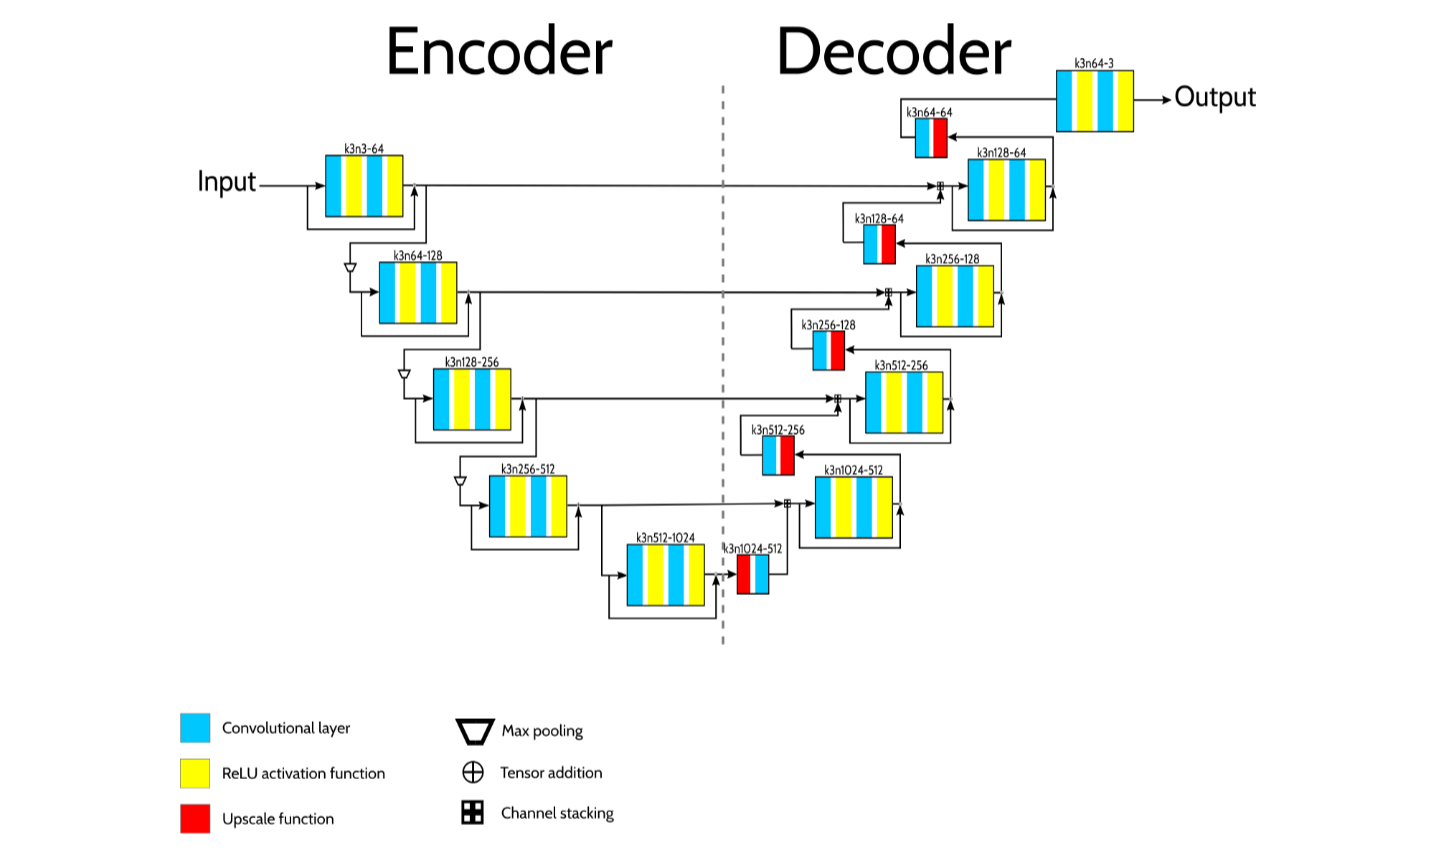

The gist of this is that the layers are arranged in a U shape, with reciprocal encoding and decoding portions.
The interesting part is that outputs from the encoding steps are saved and added
to the decoding steps. In theory, this should help with the blurryness of our final output, as
the outputs that are merged should contain more fine-grained information.

Quoting from the above linked paper:
> The reason U-Net is are favored for super-resolution tasks, or generally, any image-to-image task, is,
as mentioned, its ability to combine deep feature extraction with the original data. The data takes two
paths for every level, as seen in figure 1, one is down and up through the entire structure and the other is
horizontal over every level. The deep path allows for feature extraction while the horizontal path allows
the model to preserve any details and increases stability


more references: https://en.wikipedia.org/wiki/U-Net

In [ ]:
inputs = layers.Input((*image_size_down, 3))

residuals = []

args = {"activation": "relu", "padding": "same"}

x = inputs

filter_list = [64, 128, 256, 512]
for filters in filter_list:
    x = layers.Conv2D(filters, 3, **args)(x)
    # x = layers.Conv2D(filters, 3, **args)(x)
    residuals.append(x)
    x = layers.MaxPool2D(2)(x)

x = layers.Conv2D(2 * filters, 3, **args)(x)
# x = layers.Conv2D(2*filters, 3, **args)(x)

for filters in reversed(filter_list):
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    y = residuals.pop()
    x = layers.Concatenate(axis=-1)([x, y])
    prev_block_residual = x

    x = layers.Conv2D(2 * filters, 3, **args)(x)
    # x = layers.Conv2D(2*filters, 3, **args)(x)

    x = layers.add([x, prev_block_residual])

x = layers.UpSampling2D(4)(x)
x = layers.Conv2D(filters, 3, padding="same")(x)
# x = layers.Conv2D(filters, 3, padding='same')(x)
outputs = layers.Conv2D(3, 3, **args)(x)

model_unet = keras.Model(inputs, outputs)
model_unet.compile(
    loss=CustomLoss,
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["mae", PSNR],
)

One downside of this, as you can see below, is that this model is MASSIVE. Far more massive than the other
two, and it comes with a proportional increase in training time. 

In [ ]:
keras.utils.plot_model(model_unet, "model_unet.png", show_shapes=True)
display(Image("model_unet.png", width=200))

In [ ]:
model_unet, history_unet, stats = train_model(model_unet, "upscale_unet", epochs=20)
stats_all = pd.concat([stats_all, stats[stats_all.columns]])

We save the model at the lowest validation loss and use that, hence getting to use the model at its most efficient. 20 epochs seems sufficient, as the model shows some signs
of overfitting. We reload the model checkpoint with the best weights before continuing.

In [ ]:
fig, _ = plot_history(history_unet)
fig.suptitle("Training metrics for UNet model")

It is subtle, but I *do* see more texture and detail than in the first and second models. The improvements are mostly in the eyes and around edges. It will be obvious 
in the side-by-side comparison below.

In [ ]:
show_comparison(model_unet)

In [ ]:
psnr_all.append(print_metrics(model_unet))

### 4. Comparisons

In [ ]:
stats_all

Unet has best performance, but the trade-off is long training
times and high model complexity. If we were running this model
on a low-powered device such as a phone, I would suggest the ESPCN
model, as it is more computationally efficient without too much
loss in image quality.

In [ ]:
model_names = [
    "Reference (bilinear)",
    "Simple upscaler",
    "Efficient sub-pixel CNN",
    "UNet style upscaler",
]
fig, axs = plt.subplots(1, 2, tight_layout=True, figsize=(12, 5))

axs[0].bar(x=model_names[1:], height=stats_all["train_time"] / 60.0)
axs[0].set_ylabel("Time (minutes)")
axs[0].set_title("Total train time")

axs[1].bar(x=model_names[1:], height=stats_all["train_time"] / stats_all["epochs"])
axs[1].set_xlabel("Model Name")
axs[1].set_ylabel("Time (s)")
axs[1].set_title("Average train time per epoch")

In [ ]:
# Total params: 10,571 (41.30 KB)
# Total params: 222,386 (868.70 KB)
# Total params: 80,093,771 (305.53 MB)


complexity = [10571, 222386, 80093771]
plt.bar(model_names[1:], height=complexity)
plt.yscale("log")
plt.ylabel("Total params (log scale)")
plt.title("Model complexity\nEstimated by total params")

As mentioned earlier, all three models beat our reference benchmark,
but each get progressively better.

In [ ]:
psnr_all
fig, axs = plt.subplots()
axs.bar(x=model_names, height=psnr_all)
axs.tick_params(axis="x", labelrotation=45)
axs.set_ylim([27.0, 30.5])
axs.set_title("Mean PSNR on test set")

In [ ]:
comparision_inputs = downscaler(sample_test[0, :, :, :, :])
comparision_targets = sample_test[0, :, :, :, :]

In [ ]:
pred_ref = ops.clip(sample_test[1, :, :, :, :], 0.0, 1.0)
pred_a = ops.clip(model_simple.predict(comparision_inputs, verbose=False), 0, 1)
pred_b = ops.clip(model_espcn.predict(comparision_inputs, verbose=False), 0, 1)
pred_c = ops.clip(model_unet.predict(comparision_inputs, verbose=False), 0, 1)

In [ ]:
fig, axs = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle("Side-by-side comparisons of model predictions")
axs[0][0].set_title("Bilinear")
axs[0][1].set_title("Simple")
axs[0][2].set_title("ESPCN")
axs[0][3].set_title("UNet")

for ax in axs.flatten():
    ax.axis("off")

for i, idx in enumerate([2, 4, 5]):
    axs[i, 0].imshow(pred_ref[idx])
    axs[i, 1].imshow(pred_a[idx])
    axs[i, 2].imshow(pred_b[idx])
    axs[i, 3].imshow(pred_c[idx])

Left to right, each image gets smoother and displays less image artefacts. The UNET model seems to recreate eyes very well, in
contrast to the other models, and renders edges much more smoothly. The child's eyes on the top row are a good example of Unet 
recreating eyes.

In [ ]:
def window_image(img):
    a = image_height // 4
    b = image_height // 2

    return img[:, a:b, a:b, :]


fig, axs = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle("Side-by-side zoomed comparisons of model predictions")
axs[0][0].set_title("Bilinear")
axs[0][1].set_title("Simple")
axs[0][2].set_title("ESPCN")
axs[0][3].set_title("UNet")

for ax in axs.flatten():
    ax.axis("off")


imgs_reference_zoom = window_image(pred_ref)
pred_a_zoom = window_image(pred_a)
pred_b_zoom = window_image(pred_b)
pred_c_zoom = window_image(pred_c)

for i, idx in enumerate([2, 4, 5]):
    axs[i, 0].imshow(imgs_reference_zoom[idx])
    axs[i, 1].imshow(pred_a_zoom[idx])
    axs[i, 2].imshow(pred_b_zoom[idx])
    axs[i, 3].imshow(pred_c_zoom[idx])

Same images, but zoomed in to be able to see more detail. In the second row you can see the difference in edge smoothness. In the first row you can see the dramatic difference in the recreation of the eyes.

### 5. Conclusions and further work

UNet performs the best. If computational capacity is not a concern,
then UNet is the clear winner. However, ESPCN is a close runner up, given
it is a simpler model that trains more efficiently with a small loss
in image quality. 

Possible future work on this domain include: 
- Experiment with regularization and dropout layers
- Experiment with increasing or decreasing the depth of the
  encoder/decoder
- Creating a hybrid model by using ESPCN's DepthToSpace layers in place
  of Unet Upsampling2D layers.
- Generalizing the model by training on more diverse datasets.
- Looking into GANS and Transformer architectures.

### 6. Final Thoughts

I learned a lot in the time researching, writing, and tuning this code. 
This was a very enjoyable project, and I expect to continue tinkering
on this model well after the semester ends.